In [7]:
import cv2
import numpy as np
import random
from typing import Tuple, List
import matplotlib.pyplot as plt
import logging

#### Data preparation

##### Generating simple shapes on images

In [8]:
def random_color() -> Tuple[int, int, int]:
    return random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)


def sufficient_contrast(c1: Tuple, c2: Tuple, threshold: int = 60) -> bool:
    return sum(abs(int(a) - int(b)) for a, b in zip(c1, c2)) > threshold


def contrasting_color(background_color: Tuple, threshold: int = 60) -> Tuple:
    for _ in range(100):
        color = random_color()
        if sufficient_contrast(color, background_color, threshold):
            return color
    return tuple((x + 128) % 256 for x in background_color)

In [9]:
def draw_triangle(image: np.ndarray, background_color: Tuple) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]
    points = [(random.randint(10, width - 10), random.randint(10, height - 10)) for _ in range(3)]
    point_array = np.array(points, dtype=np.int32)
    color = contrasting_color(background_color)
    cv2.fillPoly(image, [point_array], color, lineType=cv2.LINE_AA)
    return points


def draw_quadrilateral(image: np.ndarray, background_color: Tuple) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]
    points = [(random.randint(10, width - 10), random.randint(10, height - 10)) for _ in range(4)]
    point_array = np.array(points, dtype=np.int32)
    color = contrasting_color(background_color)
    cv2.fillPoly(image, [point_array], color, lineType=cv2.LINE_AA)
    return points


def draw_star(image: np.ndarray, background_color: Tuple, min_dist: int = 15, max_dist: int = 35) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]
    color = contrasting_color(background_color)

    centered_x = random.randint(width // 4, 3 * width // 4)
    centered_y = random.randint(height // 4, 3 * height // 4)
    center = (centered_x, centered_y)

    outer = []
    attempts = 0
    while len(outer) < 5 and attempts < 200:
        angle = random.uniform(0, 2 * np.pi)
        dist = random.randint(min_dist, max_dist)
        px = int(np.clip(centered_x + dist * np.cos(angle), 10, width - 10))
        py = int(np.clip(centered_y + dist * np.sin(angle), 10, height - 10))

        if any(np.hypot(px - ox, py - oy) < min_dist for ox, oy in outer):
            attempts += 1
            continue
        outer.append((px, py))
        attempts += 1

    for pt in outer:
        cv2.line(image, center, pt, color, thickness=2, lineType=cv2.LINE_AA)

    return [center] + outer


def add_gauss_noise(image: np.ndarray, std: float = None) -> np.ndarray:
    if std is None:
        std = random.uniform(0.05, 0.15)
    noise = np.random.normal(0, std * 255, image.shape).astype(np.float32)
    noise = cv2.GaussianBlur(noise, (5, 5), 0)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

##### Generate complex shapes

In [10]:
def draw_chessboard(image: np.ndarray, background_color: Tuple, columns: int = 3, rows: int = 4) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]

    # FIX 3: simplified cell_size computation — compute once, clamp to minimum 8
    max_cell = (min(width, height) - 10) // max(columns, rows)
    cell_size = max(8, random.randint(8, max(8, max_cell)))

    board_width = columns * cell_size
    board_height = rows * cell_size

    max_ox = max(5, width - board_width - 5)
    max_oy = max(5, height - board_height - 5)

    top_left_x = random.randint(5, max_ox)
    top_left_y = random.randint(5, max_oy)

    color1 = contrasting_color(background_color)
    color2 = contrasting_color(color1, 80)

    for row in range(rows):
        for column in range(columns):
            x1 = top_left_x + column * cell_size
            y1 = top_left_y + row * cell_size
            x2 = x1 + cell_size
            y2 = y1 + cell_size
            color = color1 if (row + column) % 2 == 0 else color2
            cv2.rectangle(image, (x1, y1), (x2, y2), color, -1)

    keypoints = []
    for row in range(rows + 1):
        for column in range(columns + 1):
            x = top_left_x + column * cell_size
            y = top_left_y + row * cell_size
            keypoints.append((x, y))

    return keypoints


def draw_3d_cube(image: np.ndarray, background_color: Tuple) -> List[Tuple[int, int]]:
    height, width = image.shape[:2]
    color = contrasting_color(background_color)

    center_x = random.randint(width // 3, 2 * width // 3)
    center_y = random.randint(height // 3, 2 * height // 3)
    center = (center_x, center_y)

    min_dist = 20
    max_dist = min(width, height) // 4

    # FIX 4: fallback point now clipped to image bounds
    def random_offset_point(base_x: int, base_y: int) -> Tuple[int, int]:
        for _ in range(100):
            dx = random.randint(-max_dist, max_dist)
            dy = random.randint(-max_dist, max_dist)
            if abs(dx) > min_dist or abs(dy) > min_dist:
                px = int(np.clip(base_x + dx, 5, width - 5))
                py = int(np.clip(base_y + dy, 5, height - 5))
                return (px, py)
        # fallback: offset clamped to image bounds
        return (int(np.clip(base_x + min_dist, 5, width - 5)),
                int(np.clip(base_y + min_dist, 5, height - 5)))

    inner_point1 = random_offset_point(center_x, center_y)
    inner_point2 = random_offset_point(center_x, center_y)
    inner_point3 = random_offset_point(center_x, center_y)

    outer_point1 = random_offset_point(inner_point1[0], inner_point1[1])
    outer_point2 = random_offset_point(inner_point2[0], inner_point2[1])
    outer_point3 = random_offset_point(inner_point3[0], inner_point3[1])

    face_color_1 = contrasting_color(background_color, threshold=40)
    face_color_2 = contrasting_color(face_color_1, threshold=40)
    face_color_3 = contrasting_color(face_color_2, threshold=40)

    faces = [
        np.array([center, inner_point1, outer_point1, inner_point2], dtype=np.int32),
        np.array([center, inner_point2, outer_point2, inner_point3], dtype=np.int32),
        np.array([center, inner_point3, outer_point3, inner_point1], dtype=np.int32),
    ]

    for face, fc in zip(faces, [face_color_1, face_color_2, face_color_3]):
        cv2.fillPoly(image, [face], fc, lineType=cv2.LINE_AA)

    for face in faces:
        cv2.polylines(image, [face], isClosed=True, color=color, thickness=1, lineType=cv2.LINE_AA)

    return [center, inner_point1, inner_point2, inner_point3, outer_point1, outer_point2, outer_point3]


In [11]:
def is_shape_overlapping(existing_mask: np.ndarray, new_mask: np.ndarray) -> bool:
    return np.any(existing_mask & new_mask)


def draw_shape(
    image: np.ndarray,
    background_color: Tuple,
    shape_type: str,
    existing_mask: np.ndarray,
    max_attempts: int = 20
) -> Tuple[List[Tuple[int, int]], bool]:
    height, width = image.shape[:2]

    for _ in range(max_attempts):
        temp_img = image.copy()
        temp_mask = np.zeros((height, width), dtype=np.uint8)

        # FIX 5: updated 'triangle' call to draw_triangle (renamed above)
        if shape_type == 'triangle':
            kps = draw_triangle(temp_img, background_color)
            pts = np.array(kps, dtype=np.int32)
            cv2.fillPoly(temp_mask, [pts], 1)

        elif shape_type == 'quadrilateral':
            kps = draw_quadrilateral(temp_img, background_color)
            pts = np.array(kps, dtype=np.int32)
            cv2.fillPoly(temp_mask, [pts], 1)

        elif shape_type == 'star':
            kps = draw_star(temp_img, background_color)
            pts = np.array(kps, dtype=np.int32)
            hull = cv2.convexHull(pts)
            cv2.fillPoly(temp_mask, [hull], 1)

        elif shape_type == 'checkerboard':
            kps = draw_chessboard(temp_img, background_color)
            xs = [p[0] for p in kps]
            ys = [p[1] for p in kps]
            cv2.rectangle(temp_mask, (min(xs), min(ys)), (max(xs), max(ys)), 1, -1)

        elif shape_type == 'cube':
            kps = draw_3d_cube(temp_img, background_color)
            pts = np.array(kps, dtype=np.int32)
            hull = cv2.convexHull(pts)
            cv2.fillPoly(temp_mask, [hull], 1)

        else:
            raise ValueError(f"Unknown shape: {shape_type}")

        if not is_shape_overlapping(existing_mask, temp_mask):
            image[:] = temp_img
            existing_mask |= temp_mask
            return kps, True

    return [], False


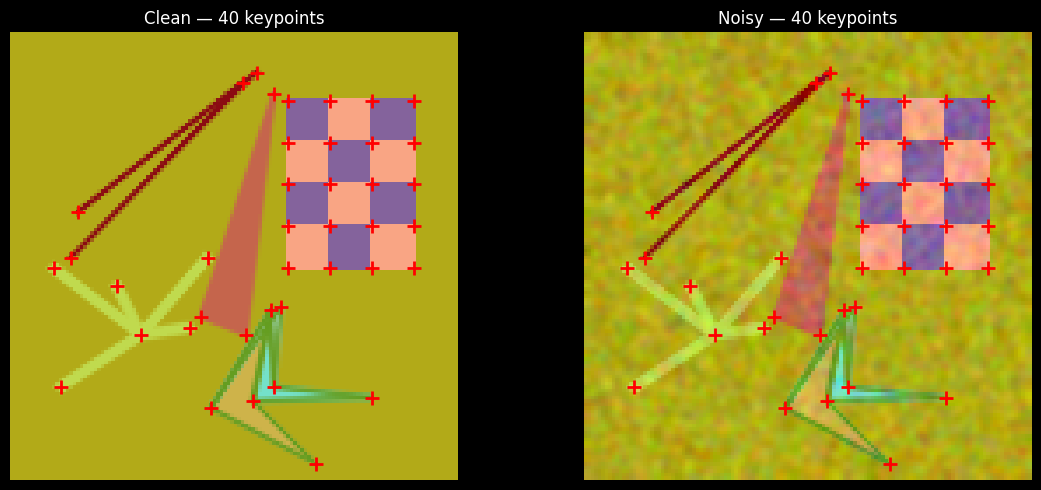

In [12]:
def generate_image(
    size: int = 128,
    shapes: List[str] = ['checkerboard', 'cube', 'quadrilateral', 'triangle', 'star']
) -> Tuple[np.ndarray, List[Tuple[int, int]]]:
    assert size % 8 == 0, "Image size must be divisible by 8"

    background_color = random_color()
    image = np.ones((size, size, 3), dtype=np.uint8) * np.array(background_color, dtype=np.uint8)
    existing_mask = np.zeros((size, size), dtype=np.uint8)

    all_keypoints = []

    for shape in shapes:
        kps, success = draw_shape(image, background_color, shape, existing_mask, max_attempts=50)
        # FIX 6: replaced print() with logging.debug to avoid stdout spam during training
        logging.debug(f"{shape}: success={success}, keypoints={len(kps)}")
        if success:
            all_keypoints.extend(kps)

    return image, all_keypoints

def visualize_sample(size: int = 128):
    shapes = ['triangle', 'quadrilateral', 'star', 'checkerboard', 'cube']
    img, keypoints = generate_image(size=size, shapes=shapes)
    img_noisy = add_gauss_noise(img)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    for ax, image, title in zip(axs, [img, img_noisy], ['Clean', 'Noisy']):
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        for (x, y) in keypoints:
            ax.plot(x, y, 'r+', markersize=10, markeredgewidth=2)
        ax.set_title(f'{title} — {len(keypoints)} keypoints')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


visualize_sample(128)

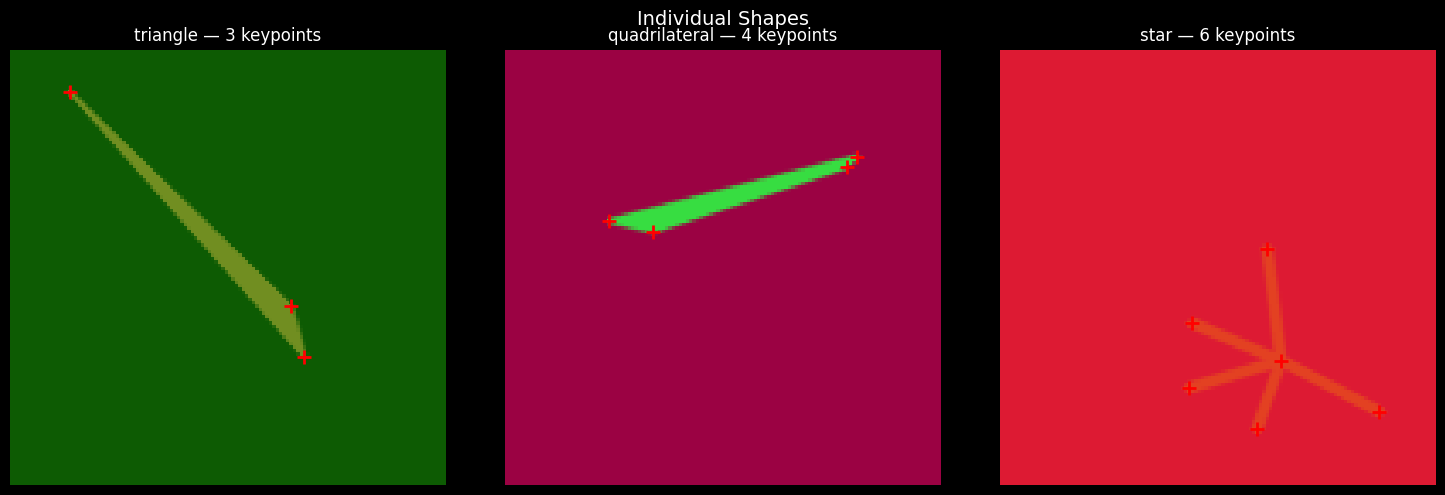

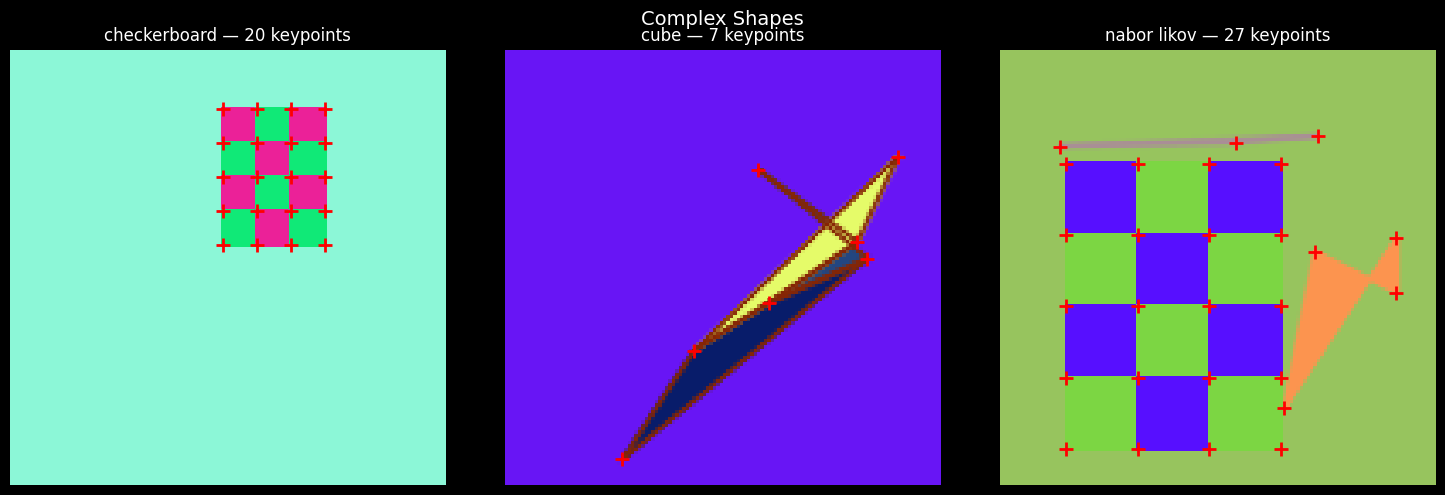

In [13]:
def visualize_individual_shapes(size: int = 128):
    """Individual shapes: triangles, quadrilaterals, stars"""
    shape_types = ['triangle', 'quadrilateral', 'star']

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Individual Shapes', fontsize=14)

    for ax, shape in zip(axs, shape_types):
        img, keypoints = generate_image(size=size, shapes=[shape])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        for (x, y) in keypoints:
            ax.plot(x, y, 'r+', markersize=10, markeredgewidth=2)
        ax.set_title(f'{shape} — {len(keypoints)} keypoints')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def visualize_complex_shapes(size: int = 128):
    """Complex shapes: checkerboard, cube, and all shapes combined"""
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Complex Shapes', fontsize=14)

    # Checkerboard only
    img1, kps1 = generate_image(size=size, shapes=['checkerboard'])
    axs[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    for (x, y) in kps1:
        axs[0].plot(x, y, 'r+', markersize=10, markeredgewidth=2)
    axs[0].set_title(f'checkerboard — {len(kps1)} keypoints')
    axs[0].axis('off')

    # Cube only
    img2, kps2 = generate_image(size=size, shapes=['cube'])
    axs[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    for (x, y) in kps2:
        axs[1].plot(x, y, 'r+', markersize=10, markeredgewidth=2)
    axs[1].set_title(f'cube — {len(kps2)} keypoints')
    axs[1].axis('off')

    # All shapes combined (nabor likov)
    img3, kps3 = generate_image(size=size, shapes=['checkerboard', 'cube', 'triangle', 'quadrilateral', 'star'])
    axs[2].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
    for (x, y) in kps3:
        axs[2].plot(x, y, 'r+', markersize=10, markeredgewidth=2)
    axs[2].set_title(f'nabor likov — {len(kps3)} keypoints')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()


# Run both
visualize_individual_shapes(128)
visualize_complex_shapes(128)

##### Homography for additional augmentation

In [18]:
def homography_points(width: int,height: int, margin: float = 0.3):
    center_x, center_y = width//2, height//2
    margin_x, margin_y = int(width*margin), int(height*margin) ## todo change the name

    points = []

    top_left_x =random.randint(0, center_x - margin_x)
    top_left_y =random.randint(0, center_y - margin_y)
    top_right_x = random.randint(center_x + margin_x, width - 1)
    top_right_y = random.randint(0, center_y - margin_y)
    bottom_left_x = random.randint(0, center_x - margin_x)
    bottom_left_y = random.randint(center_y + margin_y, height - 1)
    bottom_right_x = random.randint(center_x + margin_x, width - 1)
    bottom_right_y = random.randint(center_y + margin_y, height - 1)

    points.append((top_left_x, top_left_y))
    points.append((top_right_x, top_right_y))
    points.append((bottom_right_x, bottom_right_y))
    points.append((bottom_left_x, bottom_left_y))

    return np.array(points, dtype=np.float32)

def rotation_points(points: np.ndarray) -> np.ndarray:
    return np.roll(points, random.randint(0,3), axis=0) ## todo why 0 3

def compute_homography(original_points: np.ndarray, width: int, height: int):
    dst_pts = np.array([ ## change the name todo
        [0, 0],
        [width - 1, 0],
        [width - 1, height - 1],
        [0, height - 1]
    ], dtype=np.float32)

    H = cv2.getPerspectiveTransform(original_points, dst_pts)
    return H

##def warp_image(image: np.ndarray, H: np.ndarray):
##    height, width = image.shape[:2]
##    return cv2.warpPerspective(image, H, (width, height))

def warp_keypoints(keypoints: List[Tuple[int, int]], H: np.ndarray):
    if not keypoints:
        return []

    pts = np.array(keypoints, dtype=np.float32)
    pts = pts.reshape(-1, 1, 2)

    warped = cv2.perspectiveTransform(pts, H)
    warped = warped.reshape(-1, 2)

    return [(int(x), int(y)) for x, y in warped]

def filter_keypoints(keypoints, width, height):
    return [
        (x, y)
        for x, y in keypoints
        if 0 <= x < width and 0 <= y < height
    ]

def apply_random_homography(image, keypoints):
    height, width = image.shape[:2]

    # 1. sample points
    src_pts = homography_points(width, height)

    # 2. random rotation
    src_pts = rotation_points(src_pts)

    # 3. compute H
    H = compute_homography(src_pts, width, height)

    # 4. warp image
    warped_img = cv2.warpPerspective(image, H, (width, height))

    # 5. warp keypoints
    warped_kps = warp_keypoints(keypoints, H)

    # 6. filter invalid ones
    warped_kps = filter_keypoints(warped_kps, width, height)

    return warped_img, warped_kps



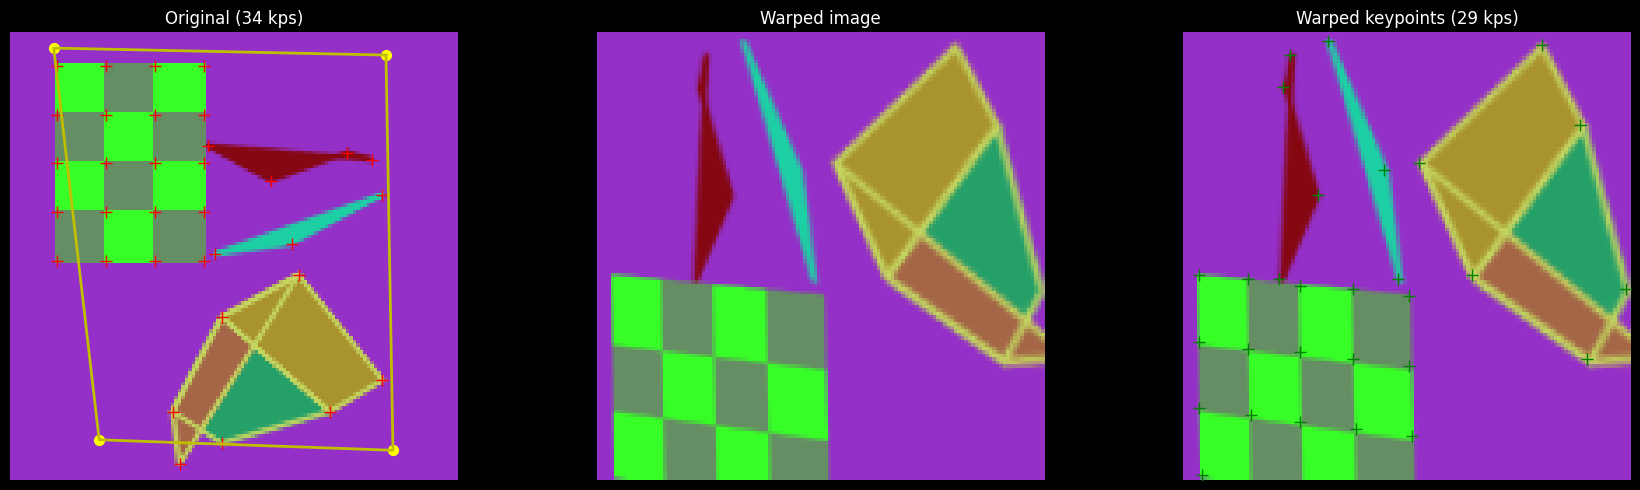

In [24]:
def visualize_homography(size: int = 128):
    shapes = ['checkerboard', 'cube', 'triangle', 'quadrilateral', 'star']

    # Generate original
    img, keypoints = generate_image(size=size, shapes=shapes)
    height, width = img.shape[:2]

    # Sample homography points
    src_pts = homography_points(width, height)
    src_pts_rot = rotation_points(src_pts)

    # Compute H
    H = compute_homography(src_pts_rot, width, height)

    # Warp
    warped_img = cv2.warpPerspective(img, H, (width, height))
    warped_kps = warp_keypoints(keypoints, H)
    warped_kps = filter_keypoints(warped_kps, width, height)

    # ---- PLOT ----
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Original image
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for (x, y) in keypoints:
        axs[0].plot(x, y, 'r+', markersize=8)
    axs[0].set_title(f'Original ({len(keypoints)} kps)')
    axs[0].axis('off')

    # Draw homography quad
    quad = np.vstack([src_pts_rot, src_pts_rot[0]])
    axs[0].plot(quad[:, 0], quad[:, 1], 'y-', linewidth=2)
    axs[0].scatter(src_pts_rot[:, 0], src_pts_rot[:, 1], c='yellow', s=50)

    # 2. Warped image
    axs[1].imshow(cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB))
    axs[1].set_title('Warped image')
    axs[1].axis('off')

    # 3. Warped + keypoints
    axs[2].imshow(cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB))
    for (x, y) in warped_kps:
        axs[2].plot(x, y, 'g+', markersize=8)
    axs[2].set_title(f'Warped keypoints ({len(warped_kps)} kps)')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_homography()

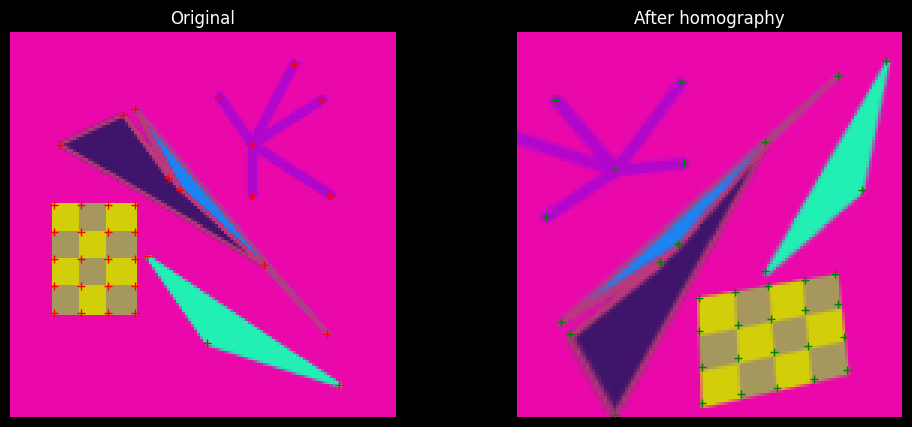

In [23]:
def visualize_keypoint_mapping(size=128):
    img, keypoints = generate_image(size=size)
    warped_img, warped_kps = apply_random_homography(img, keypoints)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for (x, y) in keypoints:
        axs[0].plot(x, y, 'r+')
    axs[0].set_title("Original")
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB))
    for (x, y) in warped_kps:
        axs[1].plot(x, y, 'g+')
    axs[1].set_title("After homography")
    axs[1].axis('off')

    plt.show()

visualize_keypoint_mapping()

In [25]:
import os

def save_sample(img, keypoints, out_dir, prefix, idx):
    os.makedirs(out_dir, exist_ok=True)

    base = os.path.join(out_dir, f"{prefix}_{idx:04d}")

    # save image
    cv2.imwrite(base + ".png", img)

    # save keypoints
    np.save(base + ".npy", np.array(keypoints, dtype=np.int32))

    # optional visualization
    vis = img.copy()
    for (x, y) in keypoints:
        cv2.circle(vis, (x, y), 3, (0, 255, 0), -1)
    cv2.imwrite(base + "_vis.png", vis)


def generate_dataset(output_dir="dataset", n=100, size=128):
    splits = ["original", "homography"]

    for split in splits:
        os.makedirs(os.path.join(output_dir, split), exist_ok=True)

    for i in range(n):
        # original
        img, kps = generate_image(size=size)
        save_sample(img, kps, f"{output_dir}/original", "img", i)

        # homography version
        h_img, h_kps = apply_random_homography(img, kps)
        save_sample(h_img, h_kps, f"{output_dir}/homography", "img", i)

    print(f"Dataset saved to {output_dir}")


generate_dataset(output_dir="dataset", n=200, size=128)


Dataset saved to dataset
